<a href="https://colab.research.google.com/github/Gustavollima17/analise-distorcao-idade-serie/blob/master/AN%C3%81LISE_DA_DISTOR%C3%87%C3%83O_IDADE_S%C3%89RIE_NO_MARANH%C3%83O.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução

# PROJETO DE PESQUISA

**Título:** Para Além do Atraso: Uma Análise dos Fatores Associados à Distorção Idade-Série no Ensino Médio do Maranhão (2023-2024)


**Objetivo:** Este estudo tem como objetivo analisar a evolução da distorção idade-série (alunos com 18 anos ou mais matriculados no Ensino Médio) nas escolas estaduais do Maranhão entre 2023 e 2024, identificando os principais fatores associados a este indicador por meio de estatística descritiva e árvore de decisão.

**Fonte dos dados:** Microdados do Censo Escolar da Educação Básica - INEP (2023 e 2024)

**Pesquisadores:** Gustavo Lima e Marcos Albino (CEST)
**Orientação:** Prof. Esp. Dadilton Bastos Melo

# Importação das bibliotecas

In [ ]:
# Importação das bibliotecas necessárias para análise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Bibliotecas importadas com sucesso.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Bibliotecas importadas com sucesso.
Pandas version: 2.2.2
NumPy version: 2.0.2


# VERIFICAÇÃO DOS ARQUIVOS DE DADOS
Os microdados do Censo Escolar são disponibilizados pelo INEP no formato CSV,
com codificação Latin-1 e separador ponto-e-vírgula (;). Os arquivos necessários são:

- microdados_ed_basica_2023.csv
- microdados_ed_basica_2024.csv

O código abaixo verifica se os arquivos estão presentes no ambiente do Colab.
Caso não estejam, solicita o upload manual.

In [ ]:
arquivo_2023 = "microdados_ed_basica_2023.csv"
arquivo_2024 = "microdados_ed_basica_2024.csv"

print("Verificando arquivos no diretório atual...")

# Listar arquivos CSV presentes
arquivos_csv = [f for f in os.listdir() if f.endswith('.csv')]
if arquivos_csv:
    print("Arquivos CSV encontrados:")
    for f in arquivos_csv:
        print(f"  - {f}")
else:
    print("Nenhum arquivo CSV encontrado.")

# Verificar arquivo de 2023
if not os.path.exists(arquivo_2023):
    print(f"\nArquivo {arquivo_2023} não encontrado.")
    print("Por favor, faça o upload do arquivo de 2023.")
    uploaded = files.upload()
    arquivo_2023 = list(uploaded.keys())[0]
    print(f"Arquivo carregado: {arquivo_2023}")
else:
    print(f"\nArquivo {arquivo_2023} encontrado.")

# Verificar arquivo de 2024
if not os.path.exists(arquivo_2024):
    print(f"\nArquivo {arquivo_2024} não encontrado.")
    print("Por favor, faça o upload do arquivo de 2024.")
    uploaded = files.upload()
    arquivo_2024 = list(uploaded.keys())[0]
    print(f"Arquivo carregado: {arquivo_2024}")
else:
    print(f"Arquivo {arquivo_2024} encontrado.")

Verificando arquivos no diretório atual...
Arquivos CSV encontrados:
  - microdados_ed_basica_2024.csv
  - microdados_ed_basica_2023.csv

Arquivo microdados_ed_basica_2023.csv encontrado.
Arquivo microdados_ed_basica_2024.csv encontrado.


# ANÁLISE DA ESTRUTURA DOS DADOS
Os microdados do Censo Escolar contêm informações detalhadas sobre as escolas
de educação básica do Brasil. Para esta pesquisa, são relevantes:

- **Variáveis de identificação:** CO_UF (código da UF), TP_DEPENDENCIA (dependência administrativa)
- **Variáveis de matrícula:** QT_MAT_MED (matrículas no EM), QT_MAT_BAS_18_MAIS (alunos com 18+)
- **Variáveis de contexto:** TP_LOCALIZACAO (urbana/rural), QT_TRANSP_PUBLICO (transporte)
- **Variáveis de infraestrutura:** indicadores de água, energia, esgoto, banheiro, internet
- **Variáveis de recursos:** laboratório, biblioteca, quadra, computador

Devido a possíveis diferenças na nomenclatura entre os anos, faremos uma
verificação prévia das colunas disponíveis.

In [ ]:
def explorar_colunas(arquivo, ano):
    """Função para identificar colunas disponíveis em cada arquivo"""
    try:
        df_sample = pd.read_csv(arquivo, encoding='latin-1', sep=';', nrows=1)
        print(f"\n[{ano}] Total de colunas: {len(df_sample.columns)}")
        print(f"[{ano}] Primeiras 20 colunas:")
        for i, col in enumerate(df_sample.columns[:20]):
            print(f"    {i+1:2d}. {col}")
        return df_sample.columns.tolist()
    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")
        return []

print("Explorando estrutura dos arquivos...")
colunas_2023 = explorar_colunas(arquivo_2023, "2023")
colunas_2024 = explorar_colunas(arquivo_2024, "2024")

Explorando estrutura dos arquivos...

[2023] Total de colunas: 408
[2023] Primeiras 20 colunas:
     1. NU_ANO_CENSO
     2. NO_REGIAO
     3. CO_REGIAO
     4. NO_UF
     5. SG_UF
     6. CO_UF
     7. NO_MUNICIPIO
     8. CO_MUNICIPIO
     9. NO_REGIAO_GEOG_INTERM
    10. CO_REGIAO_GEOG_INTERM
    11. NO_REGIAO_GEOG_IMED
    12. CO_REGIAO_GEOG_IMED
    13. NO_MESORREGIAO
    14. CO_MESORREGIAO
    15. NO_MICRORREGIAO
    16. CO_MICRORREGIAO
    17. CO_DISTRITO
    18. NO_ENTIDADE
    19. CO_ENTIDADE
    20. TP_DEPENDENCIA

[2024] Total de colunas: 426
[2024] Primeiras 20 colunas:
     1. NU_ANO_CENSO
     2. NO_REGIAO
     3. CO_REGIAO
     4. NO_UF
     5. SG_UF
     6. CO_UF
     7. NO_MUNICIPIO
     8. CO_MUNICIPIO
     9. NO_REGIAO_GEOG_INTERM
    10. CO_REGIAO_GEOG_INTERM
    11. NO_REGIAO_GEOG_IMED
    12. CO_REGIAO_GEOG_IMED
    13. NO_MESORREGIAO
    14. CO_MESORREGIAO
    15. NO_MICRORREGIAO
    16. CO_MICRORREGIAO
    17. NO_DISTRITO
    18. CO_DISTRITO
    19. NO_ENTIDADE


#  SELEÇÃO DAS VARIÁVEIS DE INTERESSE

Com base na exploração anterior, identificamos as colunas que serão utilizadas.
Para garantir consistência entre os anos, utilizaremos um mapeamento que busca
diferentes nomes possíveis para cada variável de interesse.

In [ ]:
# Dicionário de mapeamento: nome padronizado -> possíveis nomes nos arquivos
mapeamento = {
    'co_uf': ['CO_UF'],
    'tp_dependencia': ['TP_DEPENDENCIA'],
    'in_med': ['IN_MED'],
    'qt_mat_med': ['QT_MAT_MED'],
    'qt_mat_18_mais': ['QT_MAT_BAS_18_MAIS'],
    'qt_transporte': ['QT_TRANSP_PUBLICO'],
    'tp_localizacao': ['TP_LOCALIZACAO'],
    'agua': ['IN_AGUA_POTAVEL', 'IN_AGUA'],
    'energia': ['IN_ENERGIA', 'IN_ENERGIA_REDE_PUBLICA'],
    'esgoto': ['IN_ESGOTO', 'IN_ESGOTO_REDE_PUBLICA'],
    'banheiro': ['IN_BANHEIRO', 'IN_BANHEIRO_PREDIO'],
    'internet': ['IN_INTERNET', 'IN_INTERNET_ESCOLA'],
    'lab': ['IN_LABORATORIO_INFORMATICA', 'IN_LABORATORIO'],
    'biblioteca': ['IN_BIBLIOTECA', 'IN_BIBLIOTECA_SALA'],
    'quadra': ['IN_QUADRA_ESPORTES', 'IN_QUADRA'],
    'computador': ['IN_COMPUTADOR', 'QT_COMPUTADOR']
}

# Função para encontrar qual coluna realmente existe no arquivo
def encontrar_colunas_disponiveis(colunas_disponiveis, mapeamento):
    encontradas = {}
    for var_padrao, possibilidades in mapeamento.items():
        for possibilidade in possibilidades:
            if possibilidade in colunas_disponiveis:
                encontradas[var_padrao] = possibilidade
                break
    return encontradas

# Encontrar colunas disponíveis em cada ano
map_2023 = encontrar_colunas_disponiveis(colunas_2023, mapeamento)
map_2024 = encontrar_colunas_disponiveis(colunas_2024, mapeamento)

print("Colunas encontradas em 2023:")
for padrao, original in map_2023.items():
    print(f"  {padrao:15} -> {original}")

print("\nColunas encontradas em 2024:")
for padrao, original in map_2024.items():
    print(f"  {padrao:15} -> {original}")

Colunas encontradas em 2023:
  co_uf           -> CO_UF
  tp_dependencia  -> TP_DEPENDENCIA
  in_med          -> IN_MED
  qt_mat_med      -> QT_MAT_MED
  qt_mat_18_mais  -> QT_MAT_BAS_18_MAIS
  qt_transporte   -> QT_TRANSP_PUBLICO
  tp_localizacao  -> TP_LOCALIZACAO
  agua            -> IN_AGUA_POTAVEL
  energia         -> IN_ENERGIA_REDE_PUBLICA
  esgoto          -> IN_ESGOTO_REDE_PUBLICA
  banheiro        -> IN_BANHEIRO
  internet        -> IN_INTERNET
  lab             -> IN_LABORATORIO_INFORMATICA
  biblioteca      -> IN_BIBLIOTECA
  quadra          -> IN_QUADRA_ESPORTES
  computador      -> IN_COMPUTADOR

Colunas encontradas em 2024:
  co_uf           -> CO_UF
  tp_dependencia  -> TP_DEPENDENCIA
  in_med          -> IN_MED
  qt_mat_med      -> QT_MAT_MED
  qt_mat_18_mais  -> QT_MAT_BAS_18_MAIS
  qt_transporte   -> QT_TRANSP_PUBLICO
  tp_localizacao  -> TP_LOCALIZACAO
  agua            -> IN_AGUA_POTAVEL
  energia         -> IN_ENERGIA_REDE_PUBLICA
  esgoto          -> IN_ESGOTO_RE

##  CARREGAMENTO DOS DADOS

Agora carregaremos apenas as colunas identificadas em cada ano.
Para variáveis não encontradas, utilizaremos valores padrão (0) posteriormente.

# Carregar 2023

In [ ]:
# Lista de colunas a carregar (apenas as encontradas)
colunas_carregar_2023 = list(map_2023.values())

print(f"Carregando {len(colunas_carregar_2023)} colunas de 2023...")

try:
    df_2023 = pd.read_csv(
        arquivo_2023,
        encoding='latin-1',
        sep=';',
        usecols=colunas_carregar_2023,
        low_memory=False
    )

    # Renomear para nomes padronizados
    inverso = {v: k for k, v in map_2023.items()}
    df_2023.rename(columns=inverso, inplace=True)

    df_2023['ano'] = 2023
    print(f" 2023 carregado: {len(df_2023):,} escolas")

except Exception as e:
    print(f" Erro ao carregar 2023: {e}")
    # Tentativa com encoding alternativo
    df_2023 = pd.read_csv(
        arquivo_2023,
        encoding='utf-8',
        sep=';',
        usecols=colunas_carregar_2023,
        low_memory=False
    )
    inverso = {v: k for k, v in map_2023.items()}
    df_2023.rename(columns=inverso, inplace=True)
    df_2023['ano'] = 2023
    print(f" 2023 carregado (UTF-8): {len(df_2023):,} escolas")

Carregando 16 colunas de 2023...
 2023 carregado: 217,625 escolas


# Carregar 2024

In [ ]:
colunas_carregar_2024 = list(map_2024.values())

print(f"\nCarregando {len(colunas_carregar_2024)} colunas de 2024...")

try:
    df_2024 = pd.read_csv(
        arquivo_2024,
        encoding='latin-1',
        sep=';',
        usecols=colunas_carregar_2024,
        low_memory=False
    )

    inverso = {v: k for k, v in map_2024.items()}
    df_2024.rename(columns=inverso, inplace=True)

    df_2024['ano'] = 2024
    print(f" 2024 carregado: {len(df_2024):,} escolas")

except Exception as e:
    print(f" Erro ao carregar 2024: {e}")
    df_2024 = pd.read_csv(
        arquivo_2024,
        encoding='utf-8',
        sep=';',
        usecols=colunas_carregar_2024,
        low_memory=False
    )
    inverso = {v: k for k, v in map_2024.items()}
    df_2024.rename(columns=inverso, inplace=True)
    df_2024['ano'] = 2024
    print(f" 2024 carregado (UTF-8): {len(df_2024):,} escolas")


Carregando 16 colunas de 2024...
 2024 carregado: 204,885 escolas


# INTEGRAÇÃO E FILTRAGEM DOS DADOS

Após carregar os dados de ambos os anos, realizaremos:
1. Concatenação dos dataframes
2. Filtro para escolas do Maranhão (CO_UF = 21)
3. Filtro para escolas estaduais (TP_DEPENDENCIA = 2)
4. Filtro para escolas com matrículas no Ensino Médio
5. Filtro para escolas com pelo menos um aluno

In [ ]:
# Concatenar os dados
df = pd.concat([df_2023, df_2024], ignore_index=True)
print(f"Total de registros: {len(df):,}")

# Filtrar Maranhão
df = df[df['co_uf'] == 21].copy()
print(f"Escolas no Maranhão: {len(df):,}")

# Filtrar estaduais
df = df[df['tp_dependencia'] == 2].copy()
print(f"Escolas estaduais: {len(df):,}")

# Filtrar com Ensino Médio (se a coluna existir)
if 'in_med' in df.columns:
    df = df[df['in_med'] == 1].copy()
    print(f"Com Ensino Médio: {len(df):,}")

# Filtrar com alunos
df = df[df['qt_mat_med'] > 0].copy()
print(f"Com alunos: {len(df):,}")

# Verificar distribuição por ano
print("\nDistribuição por ano:")
print(df['ano'].value_counts().sort_index())

Total de registros: 422,510
Escolas no Maranhão: 27,134
Escolas estaduais: 2,627
Com Ensino Médio: 1,562
Com alunos: 1,562

Distribuição por ano:
ano
2023    784
2024    778
Name: count, dtype: int64


# CRIAÇÃO DOS INDICADORES

Para a análise, criaremos os seguintes indicadores:

- **taxa_distorcao**: percentual de alunos com 18 anos ou mais no Ensino Médio
- **infra**: escore de infraestrutura (0-5) baseado em água, energia, esgoto, banheiro, internet
- **recursos**: escore de recursos pedagógicos (0-4) baseado em lab, biblioteca, quadra, computador
- **taxa_transporte**: percentual de alunos que utilizam transporte público
- **localizacao**: classificação da escola (urbana/rural)

# Calcular Indicadores

In [ ]:
print("Calculando indicadores...")

# 1. Taxa de distorção
if 'qt_mat_18_mais' in df.columns:
    df['taxa_distorcao'] = (df['qt_mat_18_mais'] / df['qt_mat_med']) * 100
else:
    print("  AVISO: Variável qt_mat_18_mais não disponível")
    df['taxa_distorcao'] = np.nan

# 2. Infraestrutura (converter para numérico)
for col in ['agua', 'energia', 'esgoto', 'banheiro', 'internet']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df[col] = df[col].clip(0, 1)  # Garantir valores binários
    else:
        df[col] = 0
        print(f"  AVISO: {col} não disponível, assumindo 0")

df['infra'] = df[['agua', 'energia', 'esgoto', 'banheiro', 'internet']].sum(axis=1)

# 3. Recursos pedagógicos
for col in ['lab', 'biblioteca', 'quadra', 'computador']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df[col] = df[col].clip(0, 1)
    else:
        df[col] = 0
        print(f"  AVISO: {col} não disponível, assumindo 0")

df['recursos'] = df[['lab', 'biblioteca', 'quadra', 'computador']].sum(axis=1)

# 4. Taxa de transporte
if 'qt_transporte' in df.columns:
    df['qt_transporte'] = pd.to_numeric(df['qt_transporte'], errors='coerce').fillna(0)
    df['taxa_transporte'] = (df['qt_transporte'] / df['qt_mat_med']) * 100
else:
    df['taxa_transporte'] = 0
    print("  AVISO: qt_transporte não disponível, assumindo 0")

# 5. Localização
if 'tp_localizacao' in df.columns:
    df['localizacao'] = df['tp_localizacao'].map({1: 'Urbana', 2: 'Rural'})
else:
    df['localizacao'] = 'Não informado'
    print("  AVISO: tp_localizacao não disponível")

print("Indicadores calculados")

Calculando indicadores...
Indicadores calculados


# ESTATÍSTICAS DESCRITIVAS

Apresentamos as estatísticas descritivas para os anos de 2023 e 2024,
incluindo médias, desvios padrão e distribuição por localização.

# Estatísticas por Ano

In [ ]:
# Separar por ano
df_2023 = df[df['ano'] == 2023].copy()
df_2024 = df[df['ano'] == 2024].copy()

print("ESTATÍSTICAS DESCRITIVAS")

print(f"\n 2023")
print(f"Número de escolas: {len(df_2023):,}")
print(f"Total de alunos: {df_2023['qt_mat_med'].sum():,.0f}")
print(f"Média de alunos/escola: {df_2023['qt_mat_med'].mean():.0f}")

if 'taxa_distorcao' in df_2023.columns:
    print(f"\nTaxa de distorção média: {df_2023['taxa_distorcao'].mean():.2f}%")
    print(f"Desvio padrão: {df_2023['taxa_distorcao'].std():.2f}")

print(f"Infraestrutura média (0-5): {df_2023['infra'].mean():.2f}")
print(f"Recursos médios (0-4): {df_2023['recursos'].mean():.2f}")
print(f"Taxa de transporte média: {df_2023['taxa_transporte'].mean():.1f}%")

print(f"\nDistribuição por localização:")
print(df_2023['localizacao'].value_counts())

print(f"\n 2024")
print(f"Número de escolas: {len(df_2024):,}")
print(f"Total de alunos: {df_2024['qt_mat_med'].sum():,.0f}")
print(f"Média de alunos/escola: {df_2024['qt_mat_med'].mean():.0f}")

if 'taxa_distorcao' in df_2024.columns:
    print(f"\nTaxa de distorção média: {df_2024['taxa_distorcao'].mean():.2f}%")
    print(f"Desvio padrão: {df_2024['taxa_distorcao'].std():.2f}")

print(f"Infraestrutura média (0-5): {df_2024['infra'].mean():.2f}")
print(f"Recursos médios (0-4): {df_2024['recursos'].mean():.2f}")
print(f"Taxa de transporte média: {df_2024['taxa_transporte'].mean():.1f}%")

print(f"\nDistribuição por localização:")
print(df_2024['localizacao'].value_counts())

ESTATÍSTICAS DESCRITIVAS

 2023
Número de escolas: 784
Total de alunos: 251,434
Média de alunos/escola: 321

Taxa de distorção média: 35.20%
Desvio padrão: 47.01
Infraestrutura média (0-5): 3.92
Recursos médios (0-4): 2.04
Taxa de transporte média: 36.9%

Distribuição por localização:
localizacao
Urbana    503
Rural     281
Name: count, dtype: int64

 2024
Número de escolas: 778
Total de alunos: 258,040
Média de alunos/escola: 332

Taxa de distorção média: 31.79%
Desvio padrão: 37.16
Infraestrutura média (0-5): 3.95
Recursos médios (0-4): 1.99
Taxa de transporte média: 35.2%

Distribuição por localização:
localizacao
Urbana    506
Rural     272
Name: count, dtype: int64


# Comparação Urbano vs Rural

In [ ]:
# Função para calcular estatísticas por localização
def estatisticas_por_local(df, ano):
    resultado = []
    for local in df['localizacao'].unique():
        if pd.notna(local):
            df_local = df[df['localizacao'] == local]
            resultado.append({
                'ano': ano,
                'localizacao': local,
                'n_escolas': len(df_local),
                'total_alunos': df_local['qt_mat_med'].sum(),
                'distorcao_media': df_local['taxa_distorcao'].mean() if 'taxa_distorcao' in df_local.columns else np.nan,
                'infra_media': df_local['infra'].mean(),
                'recursos_media': df_local['recursos'].mean()
            })
    return pd.DataFrame(resultado)

# Calcular para ambos os anos
comparacao_2023 = estatisticas_por_local(df_2023, 2023)
comparacao_2024 = estatisticas_por_local(df_2024, 2024)

# Exibir resultados
print("\n2023:")
print(comparacao_2023.to_string(index=False))

print("\n2024:")
print(comparacao_2024.to_string(index=False))

# Calcular diferenças
if len(comparacao_2023) >= 2 and len(comparacao_2024) >= 2:
    print("\nEVOLUÇÃO DAS DIFERENÇAS:")
    dif_2023 = comparacao_2023[comparacao_2023['localizacao']=='Rural']['distorcao_media'].values[0] - \
               comparacao_2023[comparacao_2023['localizacao']=='Urbana']['distorcao_media'].values[0]

    dif_2024 = comparacao_2024[comparacao_2024['localizacao']=='Rural']['distorcao_media'].values[0] - \
               comparacao_2024[comparacao_2024['localizacao']=='Urbana']['distorcao_media'].values[0]

    print(f"Diferença Rural-Urbana 2023: {dif_2023:.2f} pontos percentuais")
    print(f"Diferença Rural-Urbana 2024: {dif_2024:.2f} pontos percentuais")
    print(f"Variação: {dif_2024 - dif_2023:+.2f} pontos")


2023:
 ano localizacao  n_escolas  total_alunos  distorcao_media  infra_media  recursos_media
2023      Urbana        503      214741.0        25.857109     4.202783        2.711730
2023       Rural        281       36693.0        51.917791     3.412811        0.846975

2024:
 ano localizacao  n_escolas  total_alunos  distorcao_media  infra_media  recursos_media
2024      Urbana        506      219872.0         24.87806     4.191700        2.592885
2024       Rural        272       38168.0         44.66209     3.492647        0.878676

EVOLUÇÃO DAS DIFERENÇAS:
Diferença Rural-Urbana 2023: 26.06 pontos percentuais
Diferença Rural-Urbana 2024: 19.78 pontos percentuais
Variação: -6.28 pontos


# VISUALIZAÇÃO DOS DADOS

Para melhor compreensão dos resultados, apresentamos gráficos comparativos
da distribuição da distorção idade-série nos dois anos.

# Gráficos

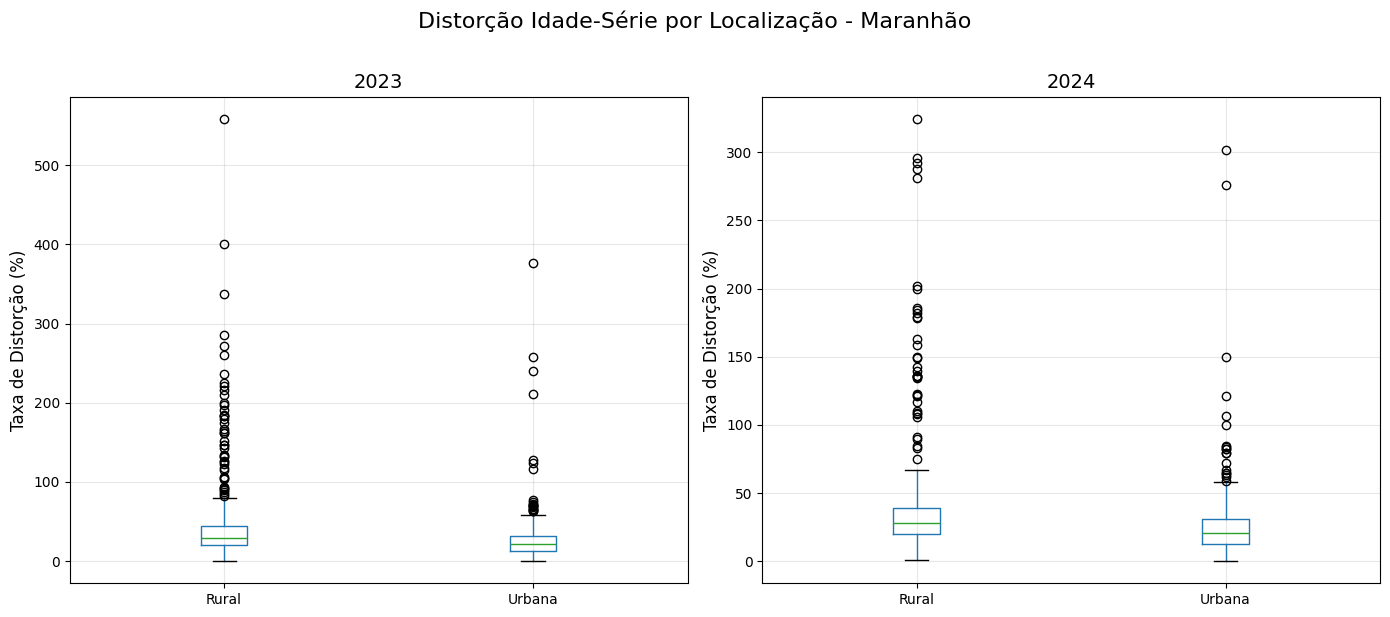

Gráfico salvo como 'comparativo_distorcao.png'


In [ ]:
# Configurar estilo dos gráficos
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Boxplot 2023
if 'taxa_distorcao' in df_2023.columns:
    df_2023.boxplot(column='taxa_distorcao', by='localizacao', ax=axes[0])
    axes[0].set_title('2023', fontsize=14)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Taxa de Distorção (%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)

# Gráfico 2: Boxplot 2024
if 'taxa_distorcao' in df_2024.columns:
    df_2024.boxplot(column='taxa_distorcao', by='localizacao', ax=axes[1])
    axes[1].set_title('2024', fontsize=14)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Taxa de Distorção (%)', fontsize=12)
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Distorção Idade-Série por Localização - Maranhão', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('comparativo_distorcao.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo como 'comparativo_distorcao.png'")

# MODELO DE ÁRVORE DE DECISÃO

Para identificar os fatores mais associados à distorção idade-série,
utilizaremos uma árvore de decisão com profundidade máxima 3.

A variável alvo será a classificação das escolas em:
- **Baixa distorção:** abaixo da mediana
- **Alta distorção:** acima da mediana

As variáveis preditoras são: infraestrutura, recursos pedagógicos,
taxa de transporte e localização (rural/urbana).



# Preparação para Árvore

In [ ]:
# Verificar se temos dados suficientes
if 'taxa_distorcao' not in df.columns or df['taxa_distorcao'].isna().all():
    print("Dados insuficientes para árvore de decisão.")
else:
    # Remover linhas com NaN na variável alvo
    df_modelo = df.dropna(subset=['taxa_distorcao']).copy()

    # Criar variável alvo (acima da mediana)
    mediana = df_modelo['taxa_distorcao'].median()
    df_modelo['alta_distorcao'] = (df_modelo['taxa_distorcao'] > mediana).astype(int)

    print(f"Mediana da distorção: {mediana:.2f}%")
    print(f"Escolas com alta distorção: {df_modelo['alta_distorcao'].sum()} de {len(df_modelo)} ({df_modelo['alta_distorcao'].mean()*100:.1f}%)")

    # Selecionar features
    features = ['infra', 'recursos', 'taxa_transporte']

    # Criar variável dummy para localização
    X = df_modelo[features].copy()
    X['rural'] = (df_modelo['localizacao'] == 'Rural').astype(int)

    # Tratar valores ausentes
    X = X.fillna(0)
    y = df_modelo['alta_distorcao']

    print(f"\nVariáveis preditoras: {X.columns.tolist()}")

Mediana da distorção: 23.85%
Escolas com alta distorção: 781 de 1562 (50.0%)

Variáveis preditoras: ['infra', 'recursos', 'taxa_transporte', 'rural']


# TREINAMENTO E AVALIAÇÃO DA ÁRVORE

In [ ]:
if 'df_modelo' in locals():
    # Dividir em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print(f"Treino: {len(X_train)} escolas")
    print(f"Teste: {len(X_test)} escolas")

    # Criar e treinar árvore
    arvore = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    )
    arvore.fit(X_train, y_train)

    # Avaliar
    y_pred = arvore.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)

    print(f"Acurácia do modelo: {acuracia*100:.2f}%")

    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=['Baixa', 'Alta']))

    # Importância das variáveis
    importancia = pd.DataFrame({
        'Variável': X.columns,
        'Importância': arvore.feature_importances_
    }).sort_values('Importância', ascending=False)

    print("\nImportância das Variáveis:")
    print(importancia.to_string(index=False))

Treino: 1093 escolas
Teste: 469 escolas
Acurácia do modelo: 62.90%

Relatório de Classificação:
              precision    recall  f1-score   support

       Baixa       0.60      0.75      0.67       235
        Alta       0.67      0.51      0.58       234

    accuracy                           0.63       469
   macro avg       0.64      0.63      0.62       469
weighted avg       0.64      0.63      0.62       469


Importância das Variáveis:
       Variável  Importância
       recursos     0.477461
          rural     0.250915
taxa_transporte     0.143102
          infra     0.128522


# Visualização da Árvore

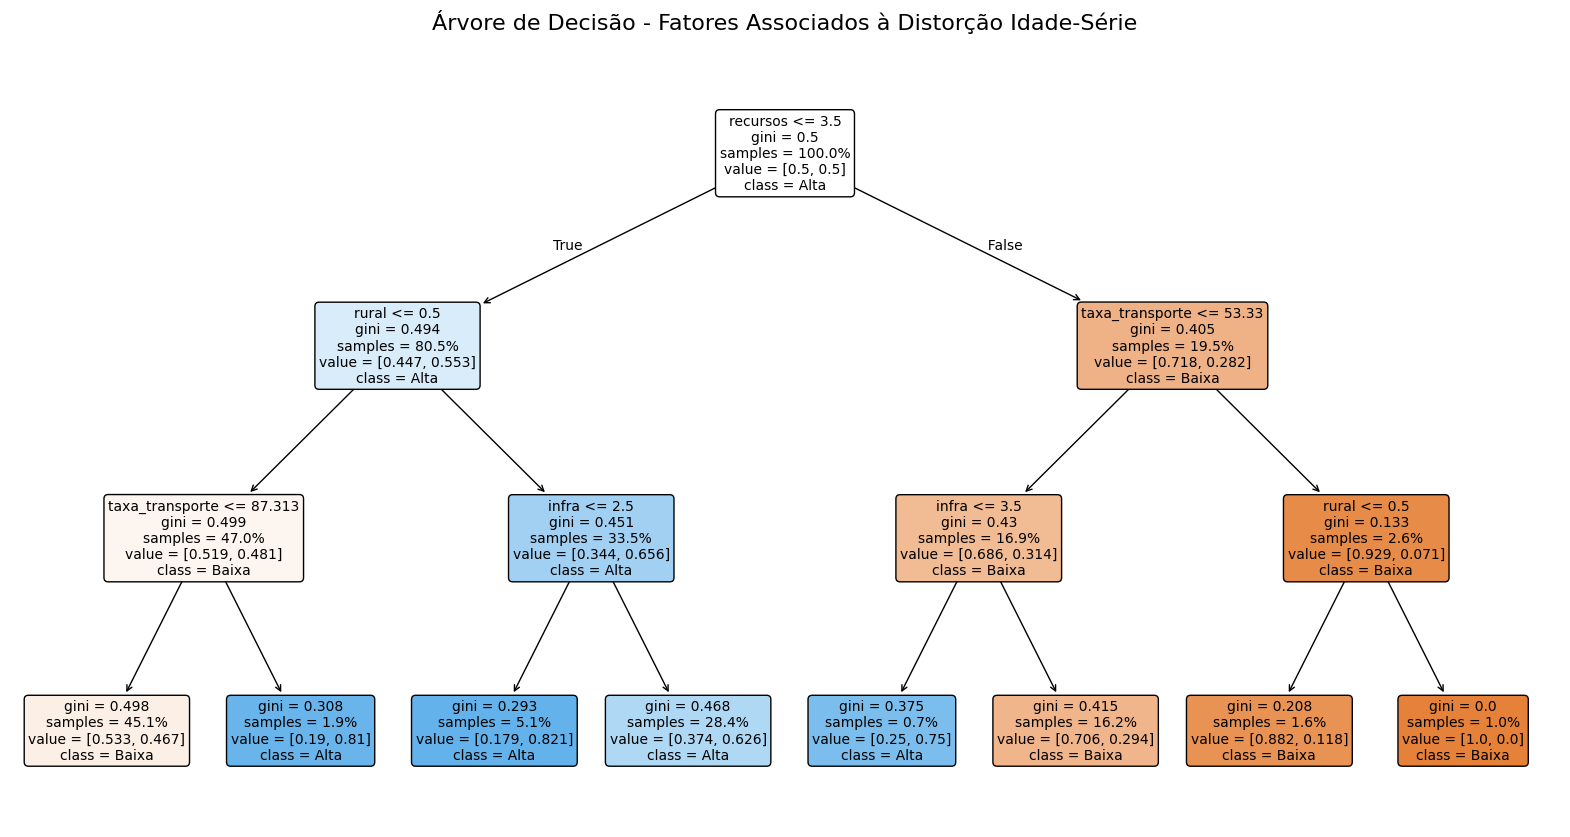

Árvore salva como 'arvore_decisao.png'


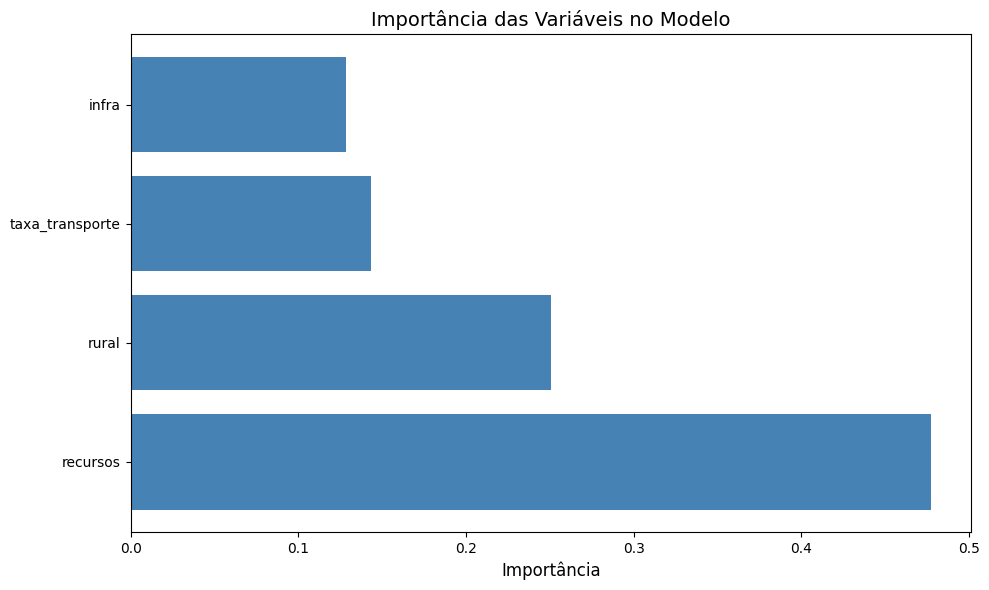

In [ ]:
if 'arvore' in locals():
    plt.figure(figsize=(20, 10))

    plot_tree(
        arvore,
        feature_names=X.columns,
        class_names=['Baixa', 'Alta'],
        filled=True,
        rounded=True,
        fontsize=10,
        proportion=True
    )

    plt.title('Árvore de Decisão - Fatores Associados à Distorção Idade-Série',
              fontsize=16, pad=20)
    plt.savefig('arvore_decisao.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Árvore salva como 'arvore_decisao.png'")

    # Gráfico de importância
    plt.figure(figsize=(10, 6))
    plt.barh(importancia['Variável'], importancia['Importância'], color='steelblue')
    plt.xlabel('Importância', fontsize=12)
    plt.title('Importância das Variáveis no Modelo', fontsize=14)
    plt.tight_layout()
    plt.savefig('importancia_variaveis.png', dpi=300, bbox_inches='tight')
    plt.show()

# EXPORTAÇÃO DOS RESULTADOS

Os resultados serão exportados em três formatos:
- **CSV:** base de dados completa para consultas futuras
- **TXT:** resumo das estatísticas para o artigo
- **PNG:** gráficos para inclusão no artigo

In [ ]:
# 1. Salvar base completa
df.to_csv('dados_maranhao_2023_2024.csv', index=False, encoding='utf-8')
print("Base salva: dados_maranhao_2023_2024.csv")

# 2. Criar resumo para o artigo
with open('resumo_artigo.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("RESULTADOS DA PESQUISA\n")
    f.write("Distorção Idade-Série no Maranhão (2023-2024)\n")
    f.write(f"Pesquisador: Gustavo Lima - CEST\n")
    f.write(f"Orientação: Prof. Esp. Dadilton Bastos Melo\n")
    f.write("="*60 + "\n\n")

    f.write("CARACTERIZAÇÃO DA AMOSTRA\n")
    f.write("-"*40 + "\n")
    f.write(f"2023: {len(df_2023)} escolas, {df_2023['qt_mat_med'].sum():,.0f} alunos\n")
    f.write(f"2024: {len(df_2024)} escolas, {df_2024['qt_mat_med'].sum():,.0f} alunos\n\n")

    f.write("2. TAXA DE DISTORÇÃO MÉDIA\n")
    f.write("-"*40 + "\n")
    if 'taxa_distorcao' in df_2023.columns:
        f.write(f"2023: {df_2023['taxa_distorcao'].mean():.2f}%\n")
        f.write(f"2024: {df_2024['taxa_distorcao'].mean():.2f}%\n")
        f.write(f"Variação: {df_2024['taxa_distorcao'].mean() - df_2023['taxa_distorcao'].mean():+.2f} pontos\n\n")

    f.write("INFRAESTRUTURA (0-5)\n")
    f.write("-"*40 + "\n")
    f.write(f"2023: {df_2023['infra'].mean():.2f}\n")
    f.write(f"2024: {df_2024['infra'].mean():.2f}\n\n")

    f.write("RECURSOS PEDAGÓGICOS (0-4)\n")
    f.write("-"*40 + "\n")
    f.write(f"2023: {df_2023['recursos'].mean():.2f}\n")
    f.write(f"2024: {df_2024['recursos'].mean():.2f}\n\n")

    if 'comparacao_2023' in locals() and len(comparacao_2023) > 0:
        f.write("COMPARAÇÃO URBANO vs RURAL\n")
        f.write("-"*40 + "\n")
        for _, row in comparacao_2023.iterrows():
            f.write(f"2023 - {row['localizacao']}: {row['distorcao_media']:.2f}%\n")
        for _, row in comparacao_2024.iterrows():
            f.write(f"2024 - {row['localizacao']}: {row['distorcao_media']:.2f}%\n")
        f.write(f"\nDiferença Rural-Urbana 2023: {dif_2023:.2f} pontos\n")
        f.write(f"Diferença Rural-Urbana 2024: {dif_2024:.2f} pontos\n\n")

    if 'importancia' in locals():
        f.write("MODELO DE ÁRVORE DE DECISÃO\n")
        f.write("-"*40 + "\n")
        f.write(f"Acurácia: {acuracia*100:.2f}%\n")
        f.write("Importância das variáveis:\n")
        for _, row in importancia.iterrows():
            f.write(f"  - {row['Variável']}: {row['Importância']:.3f}\n")

print("\nResumo salvo: resumo_artigo.txt")

# 3. Download dos arquivos
print("\nIniciando download dos arquivos...")
files.download('dados_maranhao_2023_2024.csv')
files.download('resumo_artigo.txt')
files.download('comparativo_distorcao.png')
if 'arvore' in locals():
    files.download('arvore_decisao.png')
    files.download('importancia_variaveis.png')


print("ANÁLISE CONCLUÍDA COM SUCESSO!")

print("\nArquivos gerados:")
print("  - dados_maranhao_2023_2024.csv (base completa)")
print("  - resumo_artigo.txt (resultados para o artigo)")
print("  - comparativo_distorcao.png (gráfico comparativo)")
if 'arvore' in locals():
    print("  - arvore_decisao.png (visualização da árvore)")
    print("  - importancia_variaveis.png (gráfico de importância)")
print("\nGustavo Lima e Marcos Albino - CEST")
print("Orientador: Prof. Esp. Dadilton Bastos Melo")

Base salva: dados_maranhao_2023_2024.csv

Resumo salvo: resumo_artigo.txt

Iniciando download dos arquivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ANÁLISE CONCLUÍDA COM SUCESSO!

Arquivos gerados:
  - dados_maranhao_2023_2024.csv (base completa)
  - resumo_artigo.txt (resultados para o artigo)
  - comparativo_distorcao.png (gráfico comparativo)
  - arvore_decisao.png (visualização da árvore)
  - importancia_variaveis.png (gráfico de importância)

Gustavo Lima e Marcos Albino - CEST
Orientador: Prof. Esp. Dadilton Bastos Melo
